# Multi-Goal Financial Asset Recommender System - MVP

- **[TEAM MEMBER A] Data Engineering & PyTorch ML**: Web Scraping, Dynamic DataFrame Preprocessing (One-Hot & NaN filling natively to CSV), Masked Weighted PyTorch Autoencoder.
- **[TEAM MEMBER B] Scoring & Allocation**: Similarity Score, Dynamic K Filter, Softmax.
- **[TEAM MEMBER C] SORR Simulation**: Evaluation loops, Path-Dependent withdrawals, GFR, ETV.
- **[UNIFIED DASHBOARD]**: Centralized Config and Hyperparameter Search.


In [1]:
%pip install yfinance matplotlib seaborn scipy lxml html5lib requests tqdm nbformat torch
from IPython.display import display
import sqlite3
import pandas as pd
import numpy as np
import io
import math, time, os, requests
from scipy.stats import norm
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('default')
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


c:\Users\tsao1\OneDrive\Documents\workspace\stock-recommender\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## [TEAM MEMBER A] Layer 1: Data Scraping & PyTorch Embeddings

In [2]:
def fetch_macro_universe():
    import time, requests, io
    import pandas as pd
    print(f"[{time.strftime('%H:%M:%S')}] [Member A] Fetching latest S&P 1500 constituents from Wikipedia...")
    headers = {'User-Agent': 'Mozilla/5.0'}
    urls = [
        "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies",
        "https://en.wikipedia.org/wiki/List_of_S%26P_600_companies"
    ]
    tickers = []
    for u in urls:
        html = requests.get(u, headers=headers).text
        df = pd.read_html(io.StringIO(html))[0]
        tickers.extend(df['Symbol'].tolist())
        
    print(f"[{time.strftime('%H:%M:%S')}] [Member A] Fetching complete US ETF universe (~3500+ symbols) via Nasdaq FTP...")
    try:
        import urllib.request as ur
        data = ur.urlopen('ftp://ftp.nasdaqtrader.com/symboldirectory/nasdaqtraded.txt').read().decode('utf-8')
        lines = data.split('\n')
        etf_tickers = []
        for line in lines[1:]:
            parts = line.split('|')
            if len(parts) > 7 and parts[5] == 'Y' and parts[7] == 'N':
                etf_tickers.append(parts[1])
        tickers.extend(etf_tickers)
        print(f"[{time.strftime('%H:%M:%S')}] [Member A] Discovered {len(etf_tickers):,} active ETF symbols.")
    except Exception as e:
        print(f"[{time.strftime('%H:%M:%S')}] [Member A] WARNING: Nasdaq FTP scrape failed: {e}")
    
    clean_tickers = [t.replace('.', '-') for t in set(tickers)]
    print(f"[{time.strftime('%H:%M:%S')}] [Member A] Total combined macro universe: {len(clean_tickers):,} symbols.")
    return clean_tickers

def generate_dataset_member_a(tickers, config):
    """
    Member A data pipeline: download, cache, and preprocess asset data.
    
    Returns:
        (master_df, price_matrix, volume_matrix, daily_returns, drip_daily_returns)
        
    volume_matrix: raw daily volume (used by _ml_worker for log-volume targets)
    drip_daily_returns: dividend-adjusted returns if drip_reinvest=True, else None
    """
    import os, time
    import pandas as pd
    import numpy as np
    import yfinance as yf
    from tqdm.auto import tqdm

    MASTER_FILE = 'sp1500_master_research_dataset.csv'
    PRICE_FILE  = 'sp1500_price_matrix.csv'
    VOLUME_FILE = 'sp1500_volume_matrix.csv'
    DIV_CACHE   = 'sp1500_dividends.csv'
    
    mode = config.get("data_source_mode", DataSyncMode.INCREMENTAL_SYNC)
    chunk_size = config.get("yf_chunk_size", 300)
    cooldown = config.get("scrape_delay", 0.3)
    drip_enabled = config.get("drip_reinvest", False)
    
    # ---------------------------------------------------------
    # 1. LOAD CACHED DATA (IF ANY)
    # ---------------------------------------------------------
    master_df = pd.read_csv(MASTER_FILE, index_col='ticker') if os.path.exists(MASTER_FILE) else pd.DataFrame()
    
    price_matrix = pd.DataFrame()
    if os.path.exists(PRICE_FILE):
        try:
            price_matrix = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True)
            if not price_matrix.empty and price_matrix.index.tz is not None:
                price_matrix.index = price_matrix.index.tz_localize(None)
        except Exception:
            price_matrix = pd.DataFrame()

    volume_matrix = pd.DataFrame()
    if os.path.exists(VOLUME_FILE):
        try:
            volume_matrix = pd.read_csv(VOLUME_FILE, index_col=0, parse_dates=True)
            if not volume_matrix.empty and volume_matrix.index.tz is not None:
                volume_matrix.index = volume_matrix.index.tz_localize(None)
        except Exception:
            volume_matrix = pd.DataFrame()

    print(f"[{time.strftime('%H:%M:%S')}] [Member A] Booting in mode [{mode}]")
    
    if mode == DataSyncMode.OFFLINE_CSV_ONLY:
        if master_df.empty or price_matrix.empty:
            print(f"[{time.strftime('%H:%M:%S')}] [Member A] WARNING: OFFLINE selected but CSVs missing!")
        tickers_to_pull_info = []
        tickers_to_pull_price = []
        
    elif mode == DataSyncMode.FULL_REBUILD:
        if len(tickers) == 0:
            tickers = fetch_macro_universe()
        tickers_to_pull_info = tickers
        tickers_to_pull_price = tickers
        master_df = pd.DataFrame()
        price_matrix = pd.DataFrame()
        volume_matrix = pd.DataFrame()
        
    elif mode == DataSyncMode.REFRESH_FUNDAMENTALS:
        if len(tickers) == 0:
            tickers = fetch_macro_universe()
        tickers_to_pull_info = tickers
        tickers_to_pull_price = [t for t in tickers if t not in price_matrix.columns]
        
    elif mode == DataSyncMode.INCREMENTAL_SYNC:
        if len(tickers) == 0:
            tickers = fetch_macro_universe()
        tickers_to_pull_info = [t for t in tickers if t not in master_df.index]
        tickers_to_pull_price = tickers
    else:
        tickers_to_pull_info = []
        tickers_to_pull_price = []
        
    # ---------------------------------------------------------
    # 2. SYNC HISTORICAL PRICES + VOLUME
    # ---------------------------------------------------------
    if tickers_to_pull_price:
        new_tickers = [t for t in tickers_to_pull_price if t not in price_matrix.columns]
        exist_tickers = [t for t in tickers_to_pull_price if t in price_matrix.columns]
        
        # Pull newly discovered tickers from inception
        if new_tickers:
            print(f"[{time.strftime('%H:%M:%S')}] [Member A] Pulling full history for {len(new_tickers)} new tickers from {config['data_start_date']}...")
            new_price_chunks = []
            new_vol_chunks = []
            for i in tqdm(range(0, len(new_tickers), chunk_size), desc="New Tickers"):
                chunk_t = new_tickers[i:i+chunk_size]
                chunk_d = yf.download(chunk_t, ignore_tz=True, start=config["data_start_date"], group_by="ticker", auto_adjust=True, progress=False, threads=True)
                if not chunk_d.empty:
                    if isinstance(chunk_d.columns, pd.MultiIndex):
                        pm = chunk_d.xs('Close', axis=1, level=1).ffill()
                        vm = chunk_d.xs('Volume', axis=1, level=1).fillna(0)
                    else:
                        pm = pd.DataFrame({chunk_t[0]: chunk_d['Close']}).ffill()
                        vm = pd.DataFrame({chunk_t[0]: chunk_d['Volume']}).fillna(0)
                    new_price_chunks.append(pm)
                    new_vol_chunks.append(vm)
                time.sleep(cooldown)
                
            if new_price_chunks:
                new_pm = pd.concat(new_price_chunks, axis=1).dropna(axis=1, how='all')
                new_vm = pd.concat(new_vol_chunks, axis=1).dropna(axis=1, how='all')
                if new_pm.index.tz is not None:
                    new_pm.index = new_pm.index.tz_localize(None)
                    new_vm.index = new_vm.index.tz_localize(None)
                price_matrix = new_pm if price_matrix.empty else pd.concat([price_matrix, new_pm], axis=1)
                volume_matrix = new_vm if volume_matrix.empty else pd.concat([volume_matrix, new_vm], axis=1)

        # Pull existing tickers incrementally
        if exist_tickers and mode == DataSyncMode.INCREMENTAL_SYNC:
            last_dt = price_matrix.index.max()
            if pd.notna(last_dt):
                start_dt = (last_dt + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                today_str = pd.Timestamp.today().strftime('%Y-%m-%d')
                if start_dt <= today_str:
                    print(f"[{time.strftime('%H:%M:%S')}] [Member A] Incrementing {len(exist_tickers)} existing tickers starting {start_dt}...")
                    inc_price_chunks = []
                    inc_vol_chunks = []
                    for i in tqdm(range(0, len(exist_tickers), chunk_size), desc="Inc Tickers"):
                        chunk_t = exist_tickers[i:i+chunk_size]
                        chunk_d = yf.download(chunk_t, ignore_tz=True, start=start_dt, group_by="ticker", auto_adjust=True, progress=False, threads=True)
                        if not chunk_d.empty:
                            if isinstance(chunk_d.columns, pd.MultiIndex):
                                pm = chunk_d.xs('Close', axis=1, level=1).ffill()
                                vm = chunk_d.xs('Volume', axis=1, level=1).fillna(0)
                            else:
                                pm = pd.DataFrame({chunk_t[0]: chunk_d['Close']}).ffill()
                                vm = pd.DataFrame({chunk_t[0]: chunk_d['Volume']}).fillna(0)
                            inc_price_chunks.append(pm)
                            inc_vol_chunks.append(vm)
                        time.sleep(cooldown)
                    if inc_price_chunks:
                        inc_pm = pd.concat(inc_price_chunks, axis=1).dropna(axis=1, how='all')
                        inc_vm = pd.concat(inc_vol_chunks, axis=1).dropna(axis=1, how='all')
                        if inc_pm.index.tz is not None:
                            inc_pm.index = inc_pm.index.tz_localize(None)
                            inc_vm.index = inc_vm.index.tz_localize(None)
                        price_matrix = pd.concat([price_matrix, inc_pm], axis=0)
                        price_matrix = price_matrix[~price_matrix.index.duplicated(keep='last')].sort_index()
                        volume_matrix = pd.concat([volume_matrix, inc_vm], axis=0)
                        volume_matrix = volume_matrix[~volume_matrix.index.duplicated(keep='last')].sort_index()

    # ---------------------------------------------------------
    # 3. SYNC FUNDAMENTALS
    # ---------------------------------------------------------
    if len(tickers_to_pull_info) > 0:
        print(f"[{time.strftime('%H:%M:%S')}] [Member A] Fetching Info/Fundamentals for {len(tickers_to_pull_info)} tickers...")
        company_data = []
        for ticker in tqdm(tickers_to_pull_info, desc="Fundamentals"):
            if ticker == "^GSPC":
                company_data.append({"ticker": ticker, "sector": "Index/Bond", "industry": "Index", "quoteType": "ETF", "top_holdings": "['"+ticker+"']"})
                continue
            try:
                t_obj = yf.Ticker(ticker)
                info = t_obj.info
                time.sleep(cooldown)
                
                quote_type = info.get('quoteType', '')
                holdings = [ticker]
                if quote_type == 'ETF':
                    funds = getattr(t_obj, 'funds_data', None)
                    if funds and hasattr(funds, 'top_holdings') and funds.top_holdings is not None:
                        holdings = list(funds.top_holdings.index)
                
                company_record = info.copy()
                company_record['ticker'] = ticker
                company_record['quoteType'] = quote_type
                company_record['top_holdings'] = str(holdings)
                
                if 'sector' not in company_record: company_record['sector'] = 'Unknown'
                if 'industry' not in company_record: company_record['industry'] = 'Unknown'
                
                company_data.append(company_record)
            except Exception:
                pass
                
        if company_data:
            new_master_df = pd.DataFrame(company_data).set_index('ticker')
            if master_df.empty:
                master_df = new_master_df
            else:
                overlap = set(new_master_df.index).intersection(set(master_df.index))
                if overlap:
                    print(f"[{time.strftime('%H:%M:%S')}] [Member A] WARNING: {len(overlap)} fundamental conflicts. Last write wins applied.")
                combined = pd.concat([master_df, new_master_df])
                master_df = combined[~combined.index.duplicated(keep='last')]

    # ---------------------------------------------------------
    # 4. PERSIST CACHES
    # ---------------------------------------------------------
    if mode != DataSyncMode.OFFLINE_CSV_ONLY:
        if not master_df.empty:
            master_df.to_csv(MASTER_FILE)
        if not price_matrix.empty:
            price_matrix.to_csv(PRICE_FILE)
        if not volume_matrix.empty:
            volume_matrix.to_csv(VOLUME_FILE)

    # ---------------------------------------------------------
    # 5. COMPUTE RETURNS
    # ---------------------------------------------------------
    daily_returns = price_matrix.pct_change().dropna(how='all') if not price_matrix.empty else pd.DataFrame()
    
    # DRIP returns (dividend reinvestment)
    drip_daily_returns = None
    if drip_enabled and not price_matrix.empty:
        print(f"[{time.strftime('%H:%M:%S')}] [Member A] Computing dividend-adjusted (DRIP) returns...")
        try:
            div_df = pd.read_csv(DIV_CACHE, index_col=0, parse_dates=True) if os.path.exists(DIV_CACHE) else pd.DataFrame()
            if not div_df.empty:
                # Total return = price return + dividend yield
                div_yield = div_df.reindex(index=price_matrix.index, columns=price_matrix.columns).fillna(0)
                div_yield = div_yield / price_matrix.shift(1)
                div_yield = div_yield.fillna(0).clip(0, 0.5)  # cap at 50% daily yield (data error guard)
                drip_daily_returns = daily_returns + div_yield
                print(f"[{time.strftime('%H:%M:%S')}] [Member A] DRIP returns computed for {len(drip_daily_returns.columns)} tickers.")
            else:
                print(f"[{time.strftime('%H:%M:%S')}] [Member A] No dividend cache found. DRIP disabled (using price-only returns).")
        except Exception as e:
            print(f"[{time.strftime('%H:%M:%S')}] [Member A] DRIP computation failed: {e}. Using price-only returns.")

    # =========================================================================
    # 6. ML FEATURE PREPROCESSING GATE
    # =========================================================================
    print(f"\n[{time.strftime('%H:%M:%S')}] [Member A] Preprocessing Configured ML Features...")
    feature_config = config.get("ml_training_features", [])
    
    for f in feature_config:
        if f in ['hist_momentum', 'hist_volatility', 'hist_volume']:
            continue
            
        if f in master_df.columns:
            if master_df[f].dtype == 'object' or pd.api.types.is_categorical_dtype(master_df[f]) or pd.api.types.is_string_dtype(master_df[f]):
                print(f"   -> Extracting Categorical Matrix: '{f}'")
                dummies = pd.get_dummies(master_df[f], prefix=f, dtype=float)
                master_df = pd.concat([master_df, dummies], axis=1)
                master_df.drop(columns=[f], inplace=True)
            else:
                print(f"   -> Processing Numeric Vector: '{f}'")
                master_df[f] = pd.to_numeric(master_df[f], errors='coerce').fillna(0.0)
        else:
            print(f"   -> WARNING: Requested config feature '{f}' not found in master_df.")

    if mode != DataSyncMode.OFFLINE_CSV_ONLY:
        master_df.to_csv(MASTER_FILE)

    # =========================================================================
    # 7. DIAGNOSTICS
    # =========================================================================
    print("\n" + "="*50)
    print("=== DATAFRAME DIAGNOSTICS & SYSTEM MAPPING ===")
    print("="*50)
    print(f"Total Equities Tracked: {len(master_df)}")
    print(f"Total Columns Processed per Asset: {len(master_df.columns)}\n")
    print(f"All Features Extracted in Master DF:\n{list(master_df.columns)}\n")
    
    print("[PIPELINE DATA FLOW MAPPING]")
    print(f"-> Selected for ML Tensor Construction: {config.get('ml_training_features', [])}")
    print("-> Passed to Member B (Scoring Layer 2): embeddings, asset_predictions, daily_returns")
    print("-> Passed to Member C (Simulation Layer 3): daily_returns, price_matrix")
    print("-> Ignored by Logic / For Display Only: ALL OTHER COLUMNS (Data Poisoning Shield Active)")
    print(f"-> Volume Matrix: {'Loaded' if not volume_matrix.empty else 'Empty'} ({len(volume_matrix.columns)} tickers)")
    print(f"-> DRIP Returns: {'Enabled' if drip_daily_returns is not None else 'Disabled (price-only)'}")
    print("==============================================\n")
    
    numeric_cols = master_df.select_dtypes(include=[np.number]).columns
    master_df[numeric_cols] = master_df[numeric_cols].fillna(0.0)
    
    return master_df, price_matrix, volume_matrix, daily_returns, drip_daily_returns


In [3]:
# =========================================================================
# DATA DICTIONARY & VALIDATION ENGINE
# =========================================================================
# Classifies every column by data-poisoning risk for backtesting embeddings.
#
# Safety Classes:
#   SAFE_STATIC    — Time-invariant company identity (sector, country).
#                    These rarely change and are safe to use across all backtest years.
#   SLOW_CHANGING  — Changes gradually over years (employees, governance scores).
#                    Low risk but values used are TODAY's snapshot, not historical.
#   POINT_IN_TIME  — Current market/financial snapshot (price, PE, marketCap).
#                    HIGH RISK: using today's value to predict historical returns = data leakage.
#   DERIVED        — Computed per-year inside the training loop (hist_momentum, hist_volatility).
#                    Properly time-aligned. No leakage.
#   METADATA       — API/system plumbing (timestamps, IDs, booleans). Not useful for ML.
#   TEXT           — Free-text fields requiring NLP. Cannot be one-hot encoded.
#   IDENTIFIER     — Names, symbols, phone numbers, URLs. Not features.
# =========================================================================

COLUMN_SAFETY_REGISTRY = {
    # ── Company Identity (SAFE_STATIC) ──
    "sector":       ("GICS sector classification (e.g. Technology, Healthcare). ~12 unique values.", "SAFE_STATIC"),
    "sectorKey":    ("Sector key identifier (lowercase slug of sector).", "SAFE_STATIC"),
    "sectorDisp":   ("Sector display name (same as sector, alternate key).", "SAFE_STATIC"),
    "industry":     ("GICS industry sub-classification (e.g. Semiconductors). ~150 unique values.", "SAFE_STATIC"),
    "industryKey":  ("Industry key identifier (lowercase slug).", "SAFE_STATIC"),
    "industryDisp": ("Industry display name (alternate key).", "SAFE_STATIC"),
    "industrySymbol": ("Industry symbol code.", "SAFE_STATIC"),
    "quoteType":    ("Security type: EQUITY, ETF, MUTUALFUND. Defines asset class.", "SAFE_STATIC"),
    "state":        ("US state or province of company headquarters. ~50 unique values.", "SAFE_STATIC"),
    "country":      ("Country of domicile. Mostly 'United States'. ~5 unique values.", "SAFE_STATIC"),
    "city":         ("City of headquarters. ⚠️ HIGH cardinality (~800+ unique). One-hot will explode tensor width.", "SAFE_STATIC"),
    "address1":     ("Street address of HQ. ⚠️ EXTREME cardinality. Not useful for embeddings.", "IDENTIFIER"),
    "address2":     ("Street address line 2.", "IDENTIFIER"),
    "zip":          ("Postal/zip code. ⚠️ HIGH cardinality (~1000+ unique).", "SAFE_STATIC"),
    "exchange":     ("Exchange code (NMS, NYQ, etc.). ~5 unique values.", "SAFE_STATIC"),
    "fullExchangeName": ("Full exchange name (NASDAQ, NYSE, etc.).", "SAFE_STATIC"),
    "market":       ("Market identifier (e.g. us_market). Almost always the same.", "SAFE_STATIC"),
    "lastSplitFactor": ("Last stock split ratio (e.g. '4:1'). Historical event.", "SAFE_STATIC"),

    # ── Slowly Changing Fundamentals (SLOW_CHANGING) ──
    "fullTimeEmployees":    ("Number of full-time employees. Changes annually. Today's snapshot.", "SLOW_CHANGING"),
    "auditRisk":            ("ISS audit committee risk score (1-10, 10=highest). Updated ~annually.", "SLOW_CHANGING"),
    "boardRisk":            ("ISS board composition risk score (1-10). Updated ~annually.", "SLOW_CHANGING"),
    "compensationRisk":     ("ISS executive compensation risk score (1-10). Updated ~annually.", "SLOW_CHANGING"),
    "shareHolderRightsRisk": ("ISS shareholder rights risk score (1-10). Updated ~annually.", "SLOW_CHANGING"),
    "overallRisk":          ("ISS composite governance risk score (1-10). Updated ~annually.", "SLOW_CHANGING"),

    # ── Price-Derived & Market Snapshot (POINT_IN_TIME) ──
    # ⚠️ ALL of these use TODAY's price/financials. Using them in a backtest
    #    that loops through historical years causes DATA LEAKAGE because the
    #    model sees 2024 values when 'predicting' 2015 forward returns.
    "marketCap":                ("Current market cap (price × shares). ⚠️ CHANGES DAILY with stock price.", "POINT_IN_TIME"),
    "nonDilutedMarketCap":      ("Market cap excluding dilutive securities. ⚠️ Price-derived.", "POINT_IN_TIME"),
    "enterpriseValue":          ("Market cap + debt - cash. ⚠️ Price-derived.", "POINT_IN_TIME"),
    "currentPrice":             ("Current trading price.", "POINT_IN_TIME"),
    "previousClose":            ("Yesterday's closing price.", "POINT_IN_TIME"),
    "open":                     ("Today's opening price.", "POINT_IN_TIME"),
    "dayLow":                   ("Today's intraday low.", "POINT_IN_TIME"),
    "dayHigh":                  ("Today's intraday high.", "POINT_IN_TIME"),
    "regularMarketPreviousClose": ("Previous close (regular session). Duplicate of previousClose.", "POINT_IN_TIME"),
    "regularMarketOpen":        ("Opening price (regular session).", "POINT_IN_TIME"),
    "regularMarketDayLow":      ("Day low (regular session).", "POINT_IN_TIME"),
    "regularMarketDayHigh":     ("Day high (regular session).", "POINT_IN_TIME"),
    "regularMarketPrice":       ("Current regular market price.", "POINT_IN_TIME"),
    "regularMarketVolume":      ("Today's trading volume.", "POINT_IN_TIME"),
    "regularMarketChange":      ("Today's absolute price change.", "POINT_IN_TIME"),
    "regularMarketChangePercent": ("Today's price change %.", "POINT_IN_TIME"),
    "regularMarketDayRange":    ("Today's price range as string.", "POINT_IN_TIME"),
    "postMarketPrice":          ("After-hours trading price.", "POINT_IN_TIME"),
    "postMarketChange":         ("After-hours price change.", "POINT_IN_TIME"),
    "postMarketChangePercent":  ("After-hours price change %.", "POINT_IN_TIME"),
    "bid":                      ("Current best bid price.", "POINT_IN_TIME"),
    "ask":                      ("Current best ask price.", "POINT_IN_TIME"),
    "bidSize":                  ("Lot size at best bid.", "POINT_IN_TIME"),
    "askSize":                  ("Lot size at best ask.", "POINT_IN_TIME"),
    "volume":                   ("Today's trading volume.", "POINT_IN_TIME"),

    # ── Valuation Ratios (POINT_IN_TIME — numerator or denominator is current price) ──
    "beta":                         ("5-year monthly beta vs S&P 500. Computed from recent 5yr window.", "POINT_IN_TIME"),
    "trailingPE":                   ("Price / trailing 12-mo EPS. ⚠️ Numerator = current price.", "POINT_IN_TIME"),
    "forwardPE":                    ("Price / forward EPS estimate. ⚠️ Numerator = current price.", "POINT_IN_TIME"),
    "priceToBook":                  ("Price / book value per share. ⚠️ Numerator = current price.", "POINT_IN_TIME"),
    "priceToSalesTrailing12Months": ("Price / trailing 12-mo revenue/share. ⚠️ Price-derived.", "POINT_IN_TIME"),
    "enterpriseToRevenue":          ("EV / revenue. ⚠️ EV is price-derived.", "POINT_IN_TIME"),
    "enterpriseToEbitda":           ("EV / EBITDA. ⚠️ EV is price-derived.", "POINT_IN_TIME"),
    "trailingPegRatio":             ("PEG ratio (PE / growth). ⚠️ PE is price-derived.", "POINT_IN_TIME"),
    "priceEpsCurrentYear":          ("Price / current-year EPS estimate.", "POINT_IN_TIME"),

    # ── Dividend Metrics (POINT_IN_TIME) ──
    "dividendRate":                 ("Current annualized dividend ($/share).", "POINT_IN_TIME"),
    "dividendYield":                ("Annual dividend / current price. ⚠️ Price-derived.", "POINT_IN_TIME"),
    "payoutRatio":                  ("Dividends paid / net income. Last fiscal year snapshot.", "POINT_IN_TIME"),
    "fiveYearAvgDividendYield":     ("5-year average dividend yield.", "POINT_IN_TIME"),
    "trailingAnnualDividendRate":   ("Trailing 12-mo dividend ($/share).", "POINT_IN_TIME"),
    "trailingAnnualDividendYield":  ("Trailing dividend / current price. ⚠️ Price-derived.", "POINT_IN_TIME"),
    "lastDividendValue":            ("Most recent dividend payment amount.", "POINT_IN_TIME"),

    # ── Volume & Liquidity (POINT_IN_TIME) ──
    "averageVolume":            ("Average daily volume (3-month lookback).", "POINT_IN_TIME"),
    "averageVolume10days":      ("Average daily volume (10-day lookback).", "POINT_IN_TIME"),
    "averageDailyVolume10Day":  ("Average daily volume 10-day (duplicate key).", "POINT_IN_TIME"),
    "averageDailyVolume3Month": ("Average daily volume 3-month (duplicate key).", "POINT_IN_TIME"),

    # ── Technical Price Levels (POINT_IN_TIME) ──
    "fiftyDayAverage":                  ("50-day simple moving average price.", "POINT_IN_TIME"),
    "twoHundredDayAverage":             ("200-day simple moving average price.", "POINT_IN_TIME"),
    "fiftyDayAverageChange":            ("Absolute change from 50-day MA.", "POINT_IN_TIME"),
    "fiftyDayAverageChangePercent":     ("% change from 50-day MA.", "POINT_IN_TIME"),
    "twoHundredDayAverageChange":       ("Absolute change from 200-day MA.", "POINT_IN_TIME"),
    "twoHundredDayAverageChangePercent":("% change from 200-day MA.", "POINT_IN_TIME"),
    "fiftyTwoWeekLow":                  ("52-week low price.", "POINT_IN_TIME"),
    "fiftyTwoWeekHigh":                 ("52-week high price.", "POINT_IN_TIME"),
    "fiftyTwoWeekLowChange":            ("Price change from 52-week low.", "POINT_IN_TIME"),
    "fiftyTwoWeekLowChangePercent":     ("%% change from 52-week low.", "POINT_IN_TIME"),
    "fiftyTwoWeekHighChange":           ("Price change from 52-week high.", "POINT_IN_TIME"),
    "fiftyTwoWeekHighChangePercent":    ("% change from 52-week high.", "POINT_IN_TIME"),
    "fiftyTwoWeekChangePercent":        ("52-week price return %.", "POINT_IN_TIME"),
    "fiftyTwoWeekRange":                ("52-week price range as string.", "POINT_IN_TIME"),
    "52WeekChange":                     ("52-week price change ratio.", "POINT_IN_TIME"),
    "SandP52WeekChange":                ("S&P 500 52-week change (benchmark comparison).", "POINT_IN_TIME"),
    "allTimeHigh":                      ("All-time high price.", "POINT_IN_TIME"),
    "allTimeLow":                       ("All-time low price.", "POINT_IN_TIME"),

    # ── Income Statement & Margins (POINT_IN_TIME — last reported quarter/year) ──
    "profitMargins":        ("Net profit margin. Last reported quarter snapshot.", "POINT_IN_TIME"),
    "grossMargins":         ("Gross margin. Last reported quarter snapshot.", "POINT_IN_TIME"),
    "operatingMargins":     ("Operating margin. Last reported quarter snapshot.", "POINT_IN_TIME"),
    "ebitdaMargins":        ("EBITDA margin. Last reported quarter snapshot.", "POINT_IN_TIME"),
    "returnOnAssets":       ("Return on assets. Last reported snapshot.", "POINT_IN_TIME"),
    "returnOnEquity":       ("Return on equity. Last reported snapshot.", "POINT_IN_TIME"),
    "revenueGrowth":        ("Quarter-over-quarter revenue growth rate.", "POINT_IN_TIME"),
    "earningsGrowth":       ("Quarter-over-quarter earnings growth rate.", "POINT_IN_TIME"),
    "earningsQuarterlyGrowth": ("Quarterly earnings growth (duplicate key).", "POINT_IN_TIME"),
    "totalRevenue":         ("Total revenue in absolute $ (last reported).", "POINT_IN_TIME"),
    "revenuePerShare":      ("Revenue per share (last reported).", "POINT_IN_TIME"),
    "grossProfits":         ("Gross profit in absolute $ (last reported).", "POINT_IN_TIME"),
    "ebitda":               ("EBITDA in absolute $ (last reported).", "POINT_IN_TIME"),
    "netIncomeToCommon":    ("Net income to common shareholders in $ (last reported).", "POINT_IN_TIME"),

    # ── Balance Sheet (POINT_IN_TIME) ──
    "totalCash":            ("Total cash on hand in $.", "POINT_IN_TIME"),
    "totalCashPerShare":    ("Cash per share.", "POINT_IN_TIME"),
    "totalDebt":            ("Total debt in $.", "POINT_IN_TIME"),
    "debtToEquity":         ("Debt-to-equity ratio.", "POINT_IN_TIME"),
    "currentRatio":         ("Current assets / current liabilities.", "POINT_IN_TIME"),
    "quickRatio":           ("(Current assets - inventory) / current liabilities.", "POINT_IN_TIME"),
    "bookValue":            ("Book value per share.", "POINT_IN_TIME"),
    "freeCashflow":         ("Free cash flow in $.", "POINT_IN_TIME"),
    "operatingCashflow":    ("Operating cash flow in $.", "POINT_IN_TIME"),

    # ── EPS (POINT_IN_TIME) ──
    "trailingEps":              ("Trailing 12-month EPS.", "POINT_IN_TIME"),
    "forwardEps":               ("Forward EPS analyst estimate.", "POINT_IN_TIME"),
    "epsTrailingTwelveMonths":  ("EPS trailing 12 months (duplicate key).", "POINT_IN_TIME"),
    "epsForward":               ("Forward EPS (duplicate key).", "POINT_IN_TIME"),
    "epsCurrentYear":           ("Current fiscal year EPS estimate.", "POINT_IN_TIME"),

    # ── Ownership & Short Interest (POINT_IN_TIME) ──
    "floatShares":              ("Shares available for public trading.", "POINT_IN_TIME"),
    "sharesOutstanding":        ("Total shares outstanding.", "POINT_IN_TIME"),
    "impliedSharesOutstanding": ("Implied shares outstanding.", "POINT_IN_TIME"),
    "sharesShort":              ("Shares currently sold short.", "POINT_IN_TIME"),
    "sharesShortPriorMonth":    ("Shares short prior month.", "POINT_IN_TIME"),
    "sharesPercentSharesOut":   ("Short shares as % of outstanding.", "POINT_IN_TIME"),
    "shortRatio":               ("Days to cover short positions.", "POINT_IN_TIME"),
    "shortPercentOfFloat":      ("Short interest as % of float.", "POINT_IN_TIME"),
    "heldPercentInsiders":      ("% of shares held by insiders.", "POINT_IN_TIME"),
    "heldPercentInstitutions":  ("% of shares held by institutions.", "POINT_IN_TIME"),

    # ── Analyst Estimates (POINT_IN_TIME) ──
    "targetHighPrice":          ("Analyst highest price target.", "POINT_IN_TIME"),
    "targetLowPrice":           ("Analyst lowest price target.", "POINT_IN_TIME"),
    "targetMeanPrice":          ("Analyst mean price target.", "POINT_IN_TIME"),
    "targetMedianPrice":        ("Analyst median price target.", "POINT_IN_TIME"),
    "recommendationMean":       ("Analyst consensus (1=Strong Buy … 5=Sell).", "POINT_IN_TIME"),
    "recommendationKey":        ("Analyst recommendation text (buy/hold/sell).", "POINT_IN_TIME"),
    "numberOfAnalystOpinions":  ("Number of analysts covering this stock.", "POINT_IN_TIME"),
    "averageAnalystRating":     ("Average analyst rating as string.", "POINT_IN_TIME"),

    # ── Pipeline-Derived (DERIVED — computed in training loop, time-aligned) ──
    "hist_momentum":        ("Annual return for the backtest year. Computed per-year, NO leakage.", "DERIVED"),
    "hist_volatility":      ("Annualized daily vol for the backtest year. Computed per-year, NO leakage.", "DERIVED"),
    "current_volatility":   ("Annualized vol from full daily returns. Used by Member B, not embedding.", "DERIVED"),
    "top_holdings":         ("ETF top holdings list (pipeline-generated string).", "METADATA"),

    # ── Identifiers (IDENTIFIER — not useful as ML features) ──
    "phone":        ("Company phone number.", "IDENTIFIER"),
    "fax":          ("Company fax number.", "IDENTIFIER"),
    "website":      ("Company website URL.", "IDENTIFIER"),
    "irWebsite":    ("Investor relations website URL.", "IDENTIFIER"),
    "shortName":    ("Short company name.", "IDENTIFIER"),
    "longName":     ("Full legal company name.", "IDENTIFIER"),
    "displayName":  ("Display name variant.", "IDENTIFIER"),
    "symbol":       ("Ticker symbol.", "IDENTIFIER"),
    "prevName":     ("Previous company name.", "IDENTIFIER"),

    # ── Free Text (TEXT — requires NLP, cannot one-hot encode) ──
    "longBusinessSummary":  ("Full company business description paragraph.", "TEXT"),
    "companyOfficers":      ("List of company officers (structured/nested).", "TEXT"),
    "executiveTeam":        ("Executive team information.", "TEXT"),

    # ── API/System Metadata (METADATA — no ML signal) ──
    "maxAge":                   ("Cache age in seconds (yfinance internal).", "METADATA"),
    "priceHint":                ("Decimal precision for price display.", "METADATA"),
    "currency":                 ("Trading currency (mostly USD).", "METADATA"),
    "financialCurrency":        ("Reporting currency.", "METADATA"),
    "language":                 ("Language code.", "METADATA"),
    "region":                   ("Region code.", "METADATA"),
    "typeDisp":                 ("Quote type display name.", "METADATA"),
    "quoteSourceName":          ("Data source name.", "METADATA"),
    "tradeable":                ("Whether tradeable on platform (boolean).", "METADATA"),
    "triggerable":              ("Whether alerts can be set (boolean).", "METADATA"),
    "cryptoTradeable":          ("Whether crypto trading available.", "METADATA"),
    "hasPrePostMarketData":     ("Whether pre/post market data exists.", "METADATA"),
    "customPriceAlertConfidence":("Alert confidence level.", "METADATA"),
    "corporateActions":         ("Corporate actions data.", "METADATA"),
    "messageBoardId":           ("Yahoo message board ID.", "METADATA"),
    "exchangeTimezoneName":     ("Exchange timezone name.", "METADATA"),
    "exchangeTimezoneShortName":("Exchange timezone abbreviation.", "METADATA"),
    "gmtOffSetMilliseconds":    ("GMT offset in milliseconds.", "METADATA"),
    "esgPopulated":             ("Whether ESG data is populated.", "METADATA"),
    "sourceInterval":           ("Data source polling interval.", "METADATA"),
    "exchangeDataDelayedBy":    ("Data delay in seconds.", "METADATA"),
    "firstTradeDateMilliseconds":("First trade date (epoch ms).", "METADATA"),
    "marketState":              ("Current market state (REGULAR, POST, PRE).", "METADATA"),
    "regularMarketTime":        ("Timestamp of last regular trade.", "METADATA"),
    "postMarketTime":           ("Timestamp of post-market data.", "METADATA"),
    "governanceEpochDate":      ("Date of governance assessment (epoch).", "METADATA"),
    "compensationAsOfEpochDate":("Date of compensation data (epoch).", "METADATA"),
    "exDividendDate":           ("Next ex-dividend date (epoch).", "METADATA"),
    "dividendDate":             ("Next dividend payment date (epoch).", "METADATA"),
    "lastDividendDate":         ("Date of most recent dividend (epoch).", "METADATA"),
    "lastSplitDate":            ("Date of last stock split (epoch).", "METADATA"),
    "sharesShortPreviousMonthDate": ("Date of prior month short data.", "METADATA"),
    "dateShortInterest":        ("Date of short interest data.", "METADATA"),
    "lastFiscalYearEnd":        ("Last fiscal year end (epoch).", "METADATA"),
    "nextFiscalYearEnd":        ("Next fiscal year end (epoch).", "METADATA"),
    "mostRecentQuarter":        ("Most recent quarter end (epoch).", "METADATA"),
    "earningsTimestamp":        ("Next earnings date (epoch).", "METADATA"),
    "earningsTimestampStart":   ("Earnings window start (epoch).", "METADATA"),
    "earningsTimestampEnd":     ("Earnings window end (epoch).", "METADATA"),
    "earningsCallTimestampStart":("Earnings call start (epoch).", "METADATA"),
    "earningsCallTimestampEnd": ("Earnings call end (epoch).", "METADATA"),
    "isEarningsDateEstimate":   ("Whether earnings date is estimated.", "METADATA"),
    "nameChangeDate":           ("Date of company name change.", "METADATA"),
    "ipoExpectedDate":          ("Expected IPO date.", "METADATA"),
    "prevExchange":             ("Previous exchange listing.", "METADATA"),
    "exchangeTransferDate":     ("Date of exchange transfer.", "METADATA"),
}

SAFETY_ICONS = {
    "SAFE_STATIC":   "🟢",
    "SLOW_CHANGING": "🟡",
    "POINT_IN_TIME": "🔴",
    "DERIVED":       "⚪",
    "METADATA":      "⬜",
    "TEXT":          "📝",
    "IDENTIFIER":   "🏷️",
    "UNKNOWN":       "❓",
}

def _resolve_column_info(col_name):
    """Look up a column in the registry, checking for one-hot prefixes if needed."""
    if col_name in COLUMN_SAFETY_REGISTRY:
        return COLUMN_SAFETY_REGISTRY[col_name]
    # Check if this is a one-hot encoded column (e.g. 'sector_Technology')
    for prefix in COLUMN_SAFETY_REGISTRY:
        if col_name.startswith(prefix + "_"):
            parent_desc, parent_safety = COLUMN_SAFETY_REGISTRY[prefix]
            suffix = col_name[len(prefix)+1:]
            return (f"One-hot from '{prefix}' = '{suffix}'", parent_safety)
    return ("(Not in registry — review manually)", "UNKNOWN")

def run_data_diagnostics(master_df, config):
    """Print comprehensive data dictionary, fill-rate analytics, and validate ML feature config."""
    feature_config = config.get("ml_training_features", [])
    
    # ── Section 1: Full Column Inventory ──
    print("\n" + "=" * 100)
    print("  DATA DICTIONARY — ALL COLUMNS IN master_df")
    print("  Total Columns:", len(master_df.columns), " | Total Assets:", len(master_df))
    print("=" * 100)
    print(f"{'#':<5} {'Column':<42} {'Dtype':<10} {'Non-Null':<9} {'Fill%':<7} {'Safety':<15} Description")
    print("-" * 150)
    
    safety_counts = {}
    for i, col in enumerate(master_df.columns):
        dtype_str = str(master_df[col].dtype)[:8]
        non_null = int(master_df[col].notna().sum())
        fill_pct = non_null / len(master_df) * 100 if len(master_df) > 0 else 0
        desc, safety = _resolve_column_info(col)
        icon = SAFETY_ICONS.get(safety, "❓")
        safety_counts[safety] = safety_counts.get(safety, 0) + 1
        
        in_model = " ◀ IN MODEL" if col in feature_config else ""
        fill_bar = "█" * int(fill_pct // 10) + "░" * (10 - int(fill_pct // 10))
        print(f"{i:<5} {col:<42} {dtype_str:<10} {non_null:<9} {fill_bar} {fill_pct:>5.1f}%  {icon} {safety:<13} {desc}{in_model}")
    
    # ── Section 2: Safety Class Summary ──
    print("\n" + "=" * 100)
    print("  SAFETY CLASS DISTRIBUTION")
    print("=" * 100)
    for cls in ["SAFE_STATIC", "SLOW_CHANGING", "POINT_IN_TIME", "DERIVED", "METADATA", "TEXT", "IDENTIFIER", "UNKNOWN"]:
        count = safety_counts.get(cls, 0)
        if count > 0:
            print(f"  {SAFETY_ICONS.get(cls, '❓')} {cls:<16} {count:>4} columns")
    
    # ── Section 3: ML Feature Validation ──
    print("\n" + "=" * 100)
    print("  ML FEATURE VALIDATION — Checking config['ml_training_features']")
    print("=" * 100)
    
    poisoning_warnings = []
    missing_warnings = []
    
    for f in feature_config:
        desc, safety = _resolve_column_info(f)
        icon = SAFETY_ICONS.get(safety, "❓")
        
        if safety == "DERIVED":
            print(f"  ✅ '{f}' — {icon} DERIVED: Computed per-year in training loop. No data leakage.")
            continue
        
        if f in master_df.columns:
            fill = master_df[f].notna().sum() / len(master_df) * 100 if len(master_df) > 0 else 0
            uniq = master_df[f].nunique()
            is_cat = master_df[f].dtype == 'object' or pd.api.types.is_categorical_dtype(master_df[f])
            type_info = f"Categorical ({uniq} unique → {uniq} one-hot cols)" if is_cat else "Numeric"
            
            if safety == "POINT_IN_TIME":
                print(f"  ⚠️  '{f}' — {icon} POINT_IN_TIME | Fill: {fill:.1f}% | {type_info}")
                print(f"       └─ WARNING: Uses TODAY's value for all backtest years → data leakage risk!")
                poisoning_warnings.append(f)
            elif safety == "SAFE_STATIC":
                print(f"  ✅ '{f}' — {icon} SAFE_STATIC | Fill: {fill:.1f}% | {type_info}")
            elif safety == "SLOW_CHANGING":
                print(f"  🟡 '{f}' — {icon} SLOW_CHANGING | Fill: {fill:.1f}% | {type_info}")
                print(f"       └─ Note: Today's snapshot used for all years. Low risk but not historically accurate.")
            elif safety in ["METADATA", "IDENTIFIER", "TEXT"]:
                print(f"  ❌ '{f}' — {icon} {safety} | This column type is not suitable for ML training.")
            else:
                print(f"  ❓ '{f}' — {icon} {safety} | Fill: {fill:.1f}% | {type_info} — Review manually.")
        else:
            # Check if it was already one-hot expanded (e.g. 'sector' → 'sector_Technology', ...)
            dummy_cols = [c for c in master_df.columns if c.startswith(f + "_")]
            if dummy_cols:
                print(f"  ✅ '{f}' — {icon} {safety} | Already one-hot expanded → {len(dummy_cols)} columns")
            else:
                print(f"  ❌ '{f}' — NOT FOUND in master_df and no one-hot expansion detected!")
                missing_warnings.append(f)
    
    # -- Section 3.5: Predicted Input Dimensionality --
    print("\n" + "=" * 100)
    print("  PREDICTED EMBEDDING INPUT VECTOR DIMENSIONALITY")
    print("=" * 100)
    print(f"  {'Feature':<35} {'Type':<15} {'Dims':>6}   Details")
    print("  " + "-" * 95)
    
    _total_pred = 0
    _horizons = len(config.get('ml_target_horizons', [1,3,5,10,15]))
    for f in feature_config:
        if f in ['hist_momentum', 'hist_volatility']:
            print(f"  {f:<35} {'DERIVED':<15} {_horizons:>6}   Multi-horizon trailing metrics")
            _total_pred += _horizons
        elif f in master_df.columns and pd.api.types.is_numeric_dtype(master_df[f]):
            print(f"  {f:<35} {'Numeric':<15} {1:>6}")
            _total_pred += 1
        else:
            _dc = [c for c in master_df.columns if c.startswith(f + '_')]
            if _dc:
                _sample = ', '.join(_dc[:3])
                _more = f" ... +{len(_dc)-3} more" if len(_dc) > 3 else ""
                print(f"  {f:<35} {'One-Hot':<15} {len(_dc):>6}   ({_sample}{_more})")
                _total_pred += len(_dc)
            elif f in master_df.columns:
                print(f"  {f:<35} {'Numeric':<15} {1:>6}")
                _total_pred += 1
            else:
                print(f"  {f:<35} {'NOT FOUND':<15} {'--':>6}   Will be skipped by training loop")
    
    print("  " + "-" * 95)
    print(f"  {'TOTAL PREDICTED INPUT DIMS':<35} {'':<15} {_total_pred:>6}")
    
    _hl = config.get('ml_hidden_layers', [32])
    _ed = config.get('ml_embedding_dim', 8)
    _oh = len(config.get('ml_target_horizons', [])) * 2
    print(f"\n  Network Architecture Preview:")
    _enc_p = [str(_total_pred)] + [f"{h}->ReLU" for h in _hl] + [f"{_ed}(embed)"]
    _dec_p = [f"{_ed}(embed)"] + [f"{h}->ReLU" for h in reversed(_hl)] + [f"{_oh}(output)"]
    print(f"  Encoder: {' -> '.join(_enc_p)}")
    print(f"  Decoder: {' -> '.join(_dec_p)}")
    _cr = _total_pred // _ed if _ed else 0
    print(f"  Compression Ratio: {_total_pred} -> {_ed} ({_cr}:1)")
    
    if _total_pred > 0 and _hl and _total_pred > _hl[0] * 3:
        print(f"\n  WARNING: Input dims ({_total_pred}) significantly larger than first hidden layer ({_hl[0]}).")
        print(f"      Consider increasing ml_hidden_layers[0] for better gradient flow.")
    
    # ── Section 4: Fill Rate Summary ──
    print("\n" + "=" * 100)
    print("  DATA QUALITY — FILL RATE ANALYTICS")
    print("=" * 100)
    
    fill_rates = master_df.notna().mean() * 100
    
    print(f"  Columns with 100% fill:   {(fill_rates == 100).sum():>4}")
    print(f"  Columns with 80-99% fill: {((fill_rates >= 80) & (fill_rates < 100)).sum():>4}")
    print(f"  Columns with 50-79% fill: {((fill_rates >= 50) & (fill_rates < 80)).sum():>4}")
    print(f"  Columns with 20-49% fill: {((fill_rates >= 20) & (fill_rates < 50)).sum():>4}")
    print(f"  Columns with  1-19% fill: {((fill_rates > 0) & (fill_rates < 20)).sum():>4}")
    print(f"  Columns with    0% fill:  {(fill_rates == 0).sum():>4}")
    
    empty_cols = fill_rates[fill_rates == 0].index.tolist()
    if empty_cols:
        print(f"\n  ⚠️  COMPLETELY EMPTY COLUMNS ({len(empty_cols)} total):")
        for c in empty_cols[:25]:
            print(f"      • {c}")
        if len(empty_cols) > 25:
            print(f"      ... and {len(empty_cols) - 25} more")
    
    sparse_cols = fill_rates[(fill_rates > 0) & (fill_rates < 20)].sort_values()
    if len(sparse_cols) > 0:
        print(f"\n  ⚠️  VERY SPARSE COLUMNS (<20% fill, {len(sparse_cols)} total):")
        for c, pct in sparse_cols.head(15).items():
            print(f"      • {c}: {pct:.1f}%")
        if len(sparse_cols) > 15:
            print(f"      ... and {len(sparse_cols) - 15} more")
    
    # ── Section 5: Final Verdict ──
    print("\n" + "=" * 100)
    print("  VALIDATION VERDICT")
    print("=" * 100)
    
    if poisoning_warnings:
        print(f"  🔴 DATA POISONING RISK: {len(poisoning_warnings)} feature(s) are POINT_IN_TIME:")
        for f in poisoning_warnings:
            print(f"     → '{f}' — today's value will be used for ALL historical backtest years")
        print(f"     Consider removing these or accepting the leakage trade-off.")
    else:
        print(f"  ✅ No POINT_IN_TIME features in config. Clean backtest.")
    
    if missing_warnings:
        print(f"  ❌ MISSING FEATURES: {len(missing_warnings)} feature(s) not found in master_df:")
        for f in missing_warnings:
            print(f"     → '{f}'")
    else:
        print(f"  ✅ All configured features exist in master_df.")
    
    print("=" * 100 + "\n")


In [4]:
# ML classes (AssetEmbeddingNet, EarlyStopping, train_pytorch_embedding_model)
# migrated to _ml_worker.py for cleaner notebook execution and modular testing.
from _ml_worker import AssetEmbeddingNet, EarlyStopping, train_pytorch_embedding_model, run_ml_grid_search

# Member B scoring (cosine similarity, user preference vector, portfolio allocation)
# migrated to _scoring_worker.py for modularity.
from _scoring_worker import (
    cosine_similarity, vol_to_vscore, build_user_preference_vector,
    compute_performance_score, recommend_and_allocate_member_b
)

## [TEAM MEMBER B] Layer 2: Scoring, Dynamic K Selection & Allocation

In [5]:
# ==========================================
# 0. CONSTANTS & ENUMS
# ==========================================
class DataSyncMode:
    """
    Controls how generate_dataset_member_a syncs price and fundamental data.
    Set via PIPELINE_CONFIG["data_source_mode"].
    """
    # Load from existing CSV files only. No network calls.
    OFFLINE_CSV_ONLY = "OFFLINE_CSV_ONLY"

    # Fetch only missing price dates and new tickers. Fastest live mode.
    INCREMENTAL_SYNC = "INCREMENTAL_SYNC"

    # Destroy all cached data and re-download everything from scratch.
    # WARNING: Takes hours. Use sparingly.
    FULL_REBUILD = "FULL_REBUILD"

    # Re-download all fundamentals (.info) but keep existing price matrix.
    REFRESH_FUNDAMENTALS = "REFRESH_FUNDAMENTALS"

print("[DataSyncMode] Enum loaded:", [DataSyncMode.OFFLINE_CSV_ONLY, DataSyncMode.INCREMENTAL_SYNC, DataSyncMode.FULL_REBUILD, DataSyncMode.REFRESH_FUNDAMENTALS])

[DataSyncMode] Enum loaded: ['OFFLINE_CSV_ONLY', 'INCREMENTAL_SYNC', 'FULL_REBUILD', 'REFRESH_FUNDAMENTALS']


In [6]:
def display_dynamic_top_k(dataset, recommendations, user_profile, user_vector):
    """
    Full diagnostic display for Dynamic Top-K recommendations.
    Uses logarithmic V_score (0-10) in all outputs for interpretability.
    """
    master_df   = dataset["master_df"]
    all_scores  = recommendations["all_scores"]
    selected    = recommendations["scores"]
    weights     = recommendations["portfolio_weights"]
    theta       = recommendations["theta"]
    T           = recommendations["temperature"]
    components  = recommendations["score_components"]
    risk_budget = recommendations["risk_budget"]
    n_k         = len(selected)

    # ── Header ──────────────────────────────────────────────────────────
    print("\n" + "\u2588" * 90)
    print("\u2588  DYNAMIC TOP-K ASSET RECOMMENDATION REPORT")
    print("\u2588" * 90)
    print(f"\u2588  Profile:              {user_profile.get('profile_name', 'Custom User')}")
    print(f"\u2588  Risk Tolerance:       {user_profile['risk_tolerance']}/10")
    print(f"\u2588  Risk Budget (Glide):  {risk_budget:.3f}/10 (Linear Scale)"
          f"(V_score ceiling after multi-goal decay)")
    print(f"\u2588  Threshold (\u03b8):        {theta}  (S_i >= \u03b8 to enter portfolio)")
    print(f"\u2588  Temperature (T):      {T:.2f}  "
          f"{'(diversified — high T)' if T > 2 else '(concentrated — low T)' if T < 1 else '(balanced)'}")
    print(f"\u2588  Universe Scored:      {recommendations['total_universe']} assets")
    print(f"\u2588  Dynamic K:            {n_k} assets passed \u03b8  "
          f"({n_k/max(recommendations['total_universe'],1):.1%} of universe)")
    print("\u2588" * 90)

    # ── Visualizations ──────────────────────────────────────────────────
    fig_height = max(12, min(32, 8 + n_k * 0.18))
    hratio = [1, max(1.5, n_k * 0.05)]

    fig = plt.figure(figsize=(17, fig_height))
    gs  = fig.add_gridspec(2, 2, height_ratios=hratio)
    ax1 = fig.add_subplot(gs[0, 0])  # score histogram
    ax4 = fig.add_subplot(gs[0, 1])  # V_score vs similarity scatter
    ax3 = fig.add_subplot(gs[1, 0])  # sector pie
    ax2 = fig.add_subplot(gs[1, 1])  # weight bar chart

    fig.suptitle(
        f"Dynamic Top-K \u2014 K={n_k} | Risk Budget {risk_budget:.2f}/10 | T={T:.1f}",
        fontsize=14, fontweight="bold"
    )

    # Plot 1: Score distribution
    all_sv   = [v for v in all_scores.values() if np.isfinite(v)]
    sel_sv   = [v for v in selected.values() if np.isfinite(v)]
    if all_sv:
        ax1.hist(all_sv, bins=min(60, len(all_sv)), color="#2196F3", alpha=0.4,
                 label=f"All ({len(all_sv)})", edgecolor="white")
    if sel_sv:
        ax1.hist(sel_sv, bins=min(40, len(sel_sv)), color="#FF5722", alpha=0.7,
                 label=f"Selected K={n_k}", edgecolor="white")
    ax1.axvline(theta, color="#E91E63", linestyle="--", lw=2, label=f"\u03b8={theta}")
    ax1.set_xlabel("Composite Score S_i")
    ax1.set_ylabel("Frequency")
    ax1.set_title("Score Distribution & Dynamic K Threshold")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Weight bar chart (all K assets)
    sw  = sorted(weights.items(), key=lambda x: x[1], reverse=True)
    tpl = [t for t, _ in sw]
    wpl = [w for _, w in sw]
    bc  = plt.cm.viridis(np.linspace(0.2, 0.9, n_k))
    bars = ax2.barh(range(n_k), wpl, color=bc, edgecolor="white")
    ax2.set_yticks(range(n_k))
    ax2.set_yticklabels(tpl, fontsize=max(5, min(8, 200 // max(n_k, 1))))
    ax2.set_xlabel("Portfolio Weight")
    ax2.set_title(f"All {n_k} Portfolio Weights")
    ax2.invert_yaxis()
    for bar, wv in zip(bars, wpl):
        ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{wv:.2%}", va="center", fontsize=max(5, min(7, 200 // max(n_k, 1))))
    ax2.grid(axis="x", alpha=0.3)

    # Plot 3: Sector pie
    sector_map = {}
    for ticker in selected:
        if ticker not in master_df.index: continue
        sector = "Unknown"
        if "sector" in master_df.columns:
            s = str(master_df.loc[ticker, "sector"])
            if s != "nan": sector = s
        if sector == "Unknown":
            sc2 = [c for c in master_df.columns if c.startswith("sector_")]
            if sc2:
                hv = master_df.loc[ticker, sc2]
                hot = hv[hv == 1.0]
                if len(hot): sector = hot.index[0].replace("sector_", "")
        sector_map[sector] = sector_map.get(sector, 0) + weights.get(ticker, 0)
    if sector_map:
        ss = sorted(sector_map.items(), key=lambda x: x[1], reverse=True)
        sl = [s[:18] for s, _ in ss]; sv2 = [v for _, v in ss]
        pc = plt.cm.Set3(np.linspace(0, 1, len(sl)))
        ax3.pie(sv2, labels=sl, autopct="%1.1f%%", colors=pc,
                startangle=90, pctdistance=0.8,
                textprops={"fontsize": 7})
        ax3.set_title("Sector Allocation (by weight)")
    else:
        ax3.text(0.5, 0.5, "No sector data", ha="center", va="center")

    # Plot 4: V_score vs Similarity scatter — budget line on x-axis
    sel_t = list(selected.keys())
    uns_t = [t for t in all_scores if t not in selected]
    if uns_t:
        ux = [components[t]["V_score"] for t in uns_t if t in components]
        uy = [components[t]["similarity"] for t in uns_t if t in components]
        ax4.scatter(ux, uy, c="#BDBDBD", alpha=0.25, s=8, label="Below \u03b8")
    if sel_t:
        sx = [components[t]["V_score"] for t in sel_t if t in components]
        sy = [components[t]["similarity"] for t in sel_t if t in components]
        sw2 = [weights.get(t, 0) for t in sel_t if t in components]
        sc = ax4.scatter(sx, sy, c=sw2, cmap="hot_r", s=45,
                         edgecolors="black", lw=0.4, label="Selected (K)", zorder=5)
        plt.colorbar(sc, ax=ax4, label="Portfolio Weight", shrink=0.8)
        top5 = sorted(sel_t, key=lambda t: weights.get(t, 0), reverse=True)[:5]
        for t in top5:
            if t in components:
                ax4.annotate(t, (components[t]["V_score"], components[t]["similarity"]),
                             fontsize=7, fontweight="bold",
                             xytext=(4, 4), textcoords="offset points")
    ax4.axvline(risk_budget, color="red", linestyle=":", lw=1.5,
                label=f"Risk Budget ({risk_budget:.2f})")
    ax4.set_xlabel("V_score (Linear Capped 0-10)")
    ax4.set_ylabel("Cosine Similarity to User Vector")
    ax4.set_title("V_score vs Similarity — Constraint Check")
    ax4.set_xlim(0, 10)
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Selected Asset Table ──────────────────────────────────────────────
    sorted_sel = sorted(selected.items(), key=lambda x: x[1], reverse=True)
    W = 130
    print("\n" + "=" * W)
    print(f"  SELECTED ASSETS (K={n_k}) \u2014 Sorted by Score")
    print("=" * W)
    print(f"  {'Rank':<5} {'Ticker':<8} {'Similarity':>11} "
          f"{'Raw Vol':>9} {'V_score':>8} {'Budget':>8} "
          f"{'Penalty%':>9} {'Score':>9} | {'Weight':>8}")
    print("  " + "-" * (W - 2))
    for rank, (ticker, score) in enumerate(sorted_sel, 1):
        c = components.get(ticker, {})
        w = weights.get(ticker, 0)
        print(
            f"  {rank:<5} {ticker:<8} "
            f"{c.get('similarity', 0):>11.4f} "
            f"{c.get('raw_vol', 0):>8.1%} "
            f"{c.get('V_score', 0):>8.2f} "
            f"{c.get('risk_budget', 0):>8.2f} "
            f"{c.get('relative_penalty', 0):>8.1%} "
            f"{score:>9.4f} | {w:>8.2%}"
        )

    # ── Rejected Asset Table ─────────────────────────────────────────────
    rej = sorted(
        [(t, s) for t, s in all_scores.items() if t not in selected],
        key=lambda x: x[1], reverse=True
    )
    print("\n" + "=" * W)
    print(f"  REJECTED ASSETS (Below \u03b8={theta}) \u2014 Sorted Greatest-to-Least")
    print("=" * W)
    print(f"  {'Rank':<5} {'Ticker':<8} {'Similarity':>11} "
          f"{'Raw Vol':>9} {'V_score':>8} {'Budget':>8} "
          f"{'Penalty%':>9} {'Score':>9}")
    print("  " + "-" * (W - 2))
    for rank, (ticker, score) in enumerate(rej, 1):
        c = components.get(ticker, {})
        print(
            f"  {rank:<5} {ticker:<8} "
            f"{c.get('similarity', 0):>11.4f} "
            f"{c.get('raw_vol', 0):>8.1%} "
            f"{c.get('V_score', 0):>8.2f} "
            f"{c.get('risk_budget', 0):>8.2f} "
            f"{c.get('relative_penalty', 0):>8.1%} "
            f"{score:>9.4f}"
        )
    print("=" * W + "\n")

    # ── Portfolio Summary Stats ───────────────────────────────────────────
    wtd_vol = sum(
        weights.get(t, 0) * components[t].get("raw_vol", 0.25)
        for t in selected if t in components
    )
    wtd_vscore = sum(
        weights.get(t, 0) * components[t].get("V_score", 5.0)
        for t in selected if t in components
    )
    hhi = sum(w ** 2 for w in weights.values()) * 10000
    eff_n = 1.0 / max(sum(w ** 2 for w in weights.values()), 1e-9)

    print("=" * 65)
    print("  PORTFOLIO SUMMARY")
    print("=" * 65)
    print(f"  Weighted Avg Raw Vol:    {wtd_vol:.2%}")
    print(f"  Weighted Avg V_score:    {wtd_vscore:.2f} / 10  "
          f"(budget {risk_budget:.2f})")
    print(f"  HHI Concentration:       {hhi:.0f}  "
          f"{'(diversified)' if hhi < 1500 else '(moderate)' if hhi < 2500 else '(concentrated)'}")
    print(f"  Effective # Assets:      {eff_n:.1f}")
    print("=" * 65 + "\n")

    return {
        "k":                   n_k,
        "weighted_volatility":        wtd_vol,
        "weighted_vscore":     wtd_vscore,
        "hhi":                 hhi,
        "effective_n":         eff_n,
        "rejected_count":      len(rej),
    }


## [TEAM MEMBER C] Evaluation Framework & Simulation

In [7]:
def evaluate_portfolio_member_c(dataset, recommendations, user_profile, config=None):
    """
    Member C: Portfolio evaluation via historical rolling-window backtesting.
    
    Strategy:
        - Slice daily returns to [simulation_start_date, simulation_end_date]
        - Run rolling-window simulations across a VARIETY of historical start points
        - Each window plays out the user's full goal horizon
        - Most recent 10-15 years serve as validation windows
        
    Uses DRIP returns if available, otherwise price-only returns.
    
    Returns:
        dict with GFR, ETV, Objective_Function_Score, Total_Simulations
    """
    if config is None:
        config = PIPELINE_CONFIG
        
    weights = recommendations["portfolio_weights"]
    
    # Use DRIP returns if available, otherwise price-only
    base_returns = dataset.get("drip_daily_returns") or dataset["daily_returns"]
    
    # Filter to simulation date window
    sim_start = pd.Timestamp(config.get("simulation_start_date", "2015-01-01"))
    sim_end   = pd.Timestamp(config.get("simulation_end_date", "2026-12-31"))
    
    available_tickers = [t for t in weights.keys() if t in base_returns.columns]
    if not available_tickers:
        print(f"  WARNING: No portfolio tickers found in returns data!")
        return {"GFR": 0, "ETV": 0, "Objective_Function_Score": 0, "Total_Simulations": 0}
    
    sim_returns = base_returns[available_tickers].loc[sim_start:sim_end]
    
    # Compute portfolio-weighted daily returns
    weight_series = pd.Series({t: weights[t] for t in available_tickers})
    weight_series = weight_series / weight_series.sum()  # renormalize
    portfolio_returns = sim_returns.dot(weight_series)
    annual_returns = portfolio_returns.resample('YE').apply(lambda x: (1+x).prod() - 1)
    
    max_horizon_years = max(user_profile['goals'].keys())
    start_capital = user_profile['start_cap']
    successful_simulations, total_simulations = 0, 0
    terminal_values = []
    
    # Rolling window: try every possible start year within the simulation range
    for start_year in range(len(annual_returns) - max_horizon_years + 1):
        if start_year + max_horizon_years > len(annual_returns):
            break
            
        current_balance = start_capital
        bankrupt = False
        
        path = annual_returns.iloc[start_year:start_year+max_horizon_years]
        for year_idx, yr_return in enumerate(path):
            current_balance = current_balance * (1 + yr_return)
            actual_year = year_idx + 1
            if actual_year in user_profile['goals']:
                withdrawal = user_profile['goals'][actual_year]
                current_balance -= withdrawal
                if current_balance < 0:
                    bankrupt = True
                    break
                    
        total_simulations += 1
        if not bankrupt:
            successful_simulations += 1
            terminal_values.append(current_balance)
            
    GFR = successful_simulations / total_simulations if total_simulations > 0 else 0
    ETV = np.median(terminal_values) if len(terminal_values) > 0 else 0
    alpha = 1.0
    objective_score = (alpha * ETV) if GFR >= 0.90 else (alpha * ETV) * (GFR / 0.90)
    
    return {"GFR": GFR, "ETV": ETV, "Objective_Function_Score": objective_score, "Total_Simulations": total_simulations}


## [UNIFIED DASHBOARD] Feedback Loop & Config Optimization

In [8]:
# ==========================================
# 1. PARAMETERS & INITIALIZATION (ALL CONFIGS)
# ==========================================
PIPELINE_CONFIG = {
    # -----------------------
    # System Execution Limits
    # -----------------------
    "data_source_mode":  DataSyncMode.FULL_REBUILD,  # Or useC DataSyncMode.INCREMENTAL_SYN
    "data_start_date": "1962-01-01",
    "training_cutoff_date": "2015-01-01",
    "simulation_start_date": "2015-01-01",
    "simulation_end_date": "2026-12-31",
    "scrape_delay": 0.3,
    "yf_chunk_size": 300,
    
    # -----------------------
    # DRIP (Dividend Reinvestment)
    # -----------------------
    "drip_reinvest": False,  # True = reinvest dividends, False = hold as cash
    
    # -----------------------
    # Column Extraction Scope
    # -----------------------
    "ml_training_features": [
        "hist_momentum", "hist_volatility", "hist_volume",
        "sector", "industry",
        "state", "quoteType", "exchange",
    ],
    
    # -----------------------
    # Neural Network Geometry
    # -----------------------
    "ml_embedding_dim": 8,
    "ml_hidden_layers": [128, 64, 32],
    "ml_target_metrics": ["return", "volatility", "volume"],
    "ml_target_horizons": [1, 3, 5, 10, 15],
    "ml_horizon_weights": {1: 1.0, 3: 0.8, 5: 0.6, 10: 0.4, 15: 0.2},
    "ml_epochs": 150,
    "ml_batch_size": 64,
    "ml_learning_rate": 0.001,
    "ml_time_decay_half_life": 10,
    
    # -----------------------
    # Scoring & Portfolio (Member B)
    # -----------------------
    "scoring_sim_weight": 1.0,
    "scoring_perf_weight_range": [0.2, 2.0],
    "scoring_penalty_weight_range": [2.0, 0.2],
    "portfolio_min_k": 5,
    "portfolio_max_k": 30,
    
    # -----------------------
    # Simulation & Thresholds
    # -----------------------
    "sim_glide_path_tau": 8.0,
    "sim_v_score_anchor": 0.50,
    "sim_dynamic_k_theta": 0.5,
}

print("="*80)
print("BOOTING MEMBER A PIPELINE")
print("="*80)

if PIPELINE_CONFIG["data_source_mode"] in ["MINE_AND_CACHE", DataSyncMode.INCREMENTAL_SYNC, DataSyncMode.FULL_REBUILD, DataSyncMode.REFRESH_FUNDAMENTALS]:
    tickers_to_mine = fetch_macro_universe()
else:
    tickers_to_mine = []

master_df, price_matrix, volume_matrix, daily_returns, drip_daily_returns = generate_dataset_member_a(
    tickers=tickers_to_mine, 
    config=PIPELINE_CONFIG
)

# Run Data Dictionary & Validation Engine
run_data_diagnostics(master_df, PIPELINE_CONFIG)

# Train embedding model (with volume + optional DRIP)
DATA_CACHE = train_pytorch_embedding_model(
    master_df, price_matrix, volume_matrix, daily_returns, 
    PIPELINE_CONFIG, 
    drip_daily_returns=drip_daily_returns
)


BOOTING MEMBER A PIPELINE
[21:18:37] [Member A] Fetching latest S&P 1500 constituents from Wikipedia...
[21:18:38] [Member A] Fetching complete US ETF universe (~3500+ symbols) via Nasdaq FTP...
[21:18:41] [Member A] Discovered 5,096 active ETF symbols.
[21:18:41] [Member A] Total combined macro universe: 6,602 symbols.
[21:18:47] [Member A] Booting in mode [FULL_REBUILD]
[21:18:47] [Member A] Pulling full history for 6602 new tickers from 1962-01-01...


New Tickers:  17%|█▋        | 4/23 [01:25<06:53, 21.74s/it]HTTP Error 404: Not Found{"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IBMX"}}}
$IBMX: possibly delisted; no timezone found

1 Failed download:
['IBMX']: possibly delisted; no timezone found
New Tickers: 100%|██████████| 23/23 [10:29<00:00, 27.37s/it]


[21:29:20] [Member A] Fetching Info/Fundamentals for 6602 tickers...


Fundamentals: 100%|██████████| 6602/6602 [54:36<00:00,  2.01it/s]



[22:31:34] [Member A] Preprocessing Configured ML Features...
   -> Extracting Categorical Matrix: 'sector'
   -> Extracting Categorical Matrix: 'industry'
   -> Extracting Categorical Matrix: 'state'
   -> Extracting Categorical Matrix: 'quoteType'
   -> Extracting Categorical Matrix: 'exchange'

=== DATAFRAME DIAGNOSTICS & SYSTEM MAPPING ===
Total Equities Tracked: 6544
Total Columns Processed per Asset: 414

All Features Extracted in Master DF:
['longBusinessSummary', 'companyOfficers', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'trailingPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'yield', 'totalAssets', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendRate', 'trai

## [PART B] Dynamic Top-K Recommendation — Multi-Profile Demonstration

This section tests the full Member B pipeline by running **three distinct user profiles** through the system:
1. **Conservative Retiree** — Low risk, high near-term withdrawal needs
2. **Balanced Growth** — Moderate risk, medium-term goals
3. **Aggressive Young Investor** — High risk, long-term growth focus

For each profile, the system:
- Constructs a **user preference vector** from the trained embedding space
- Scores the entire asset universe via **cosine similarity + volatility penalty**
- Applies **Dynamic K thresholding** (θ) to select the optimal asset set
- Computes **temperature-scaled softmax weights** for allocation
- Visualizes the results with score distributions, sector breakdowns, and weight charts


════════════════════════════════════════════════════════════════════════════════
  TESTING PROFILE: Conservative Retiree
════════════════════════════════════════════════════════════════════════════════

██████████████████████████████████████████████████████████████████████████████████████████
█  DYNAMIC TOP-K ASSET RECOMMENDATION REPORT
██████████████████████████████████████████████████████████████████████████████████████████
█  Profile:              Conservative Retiree
█  Risk Tolerance:       2.0/10
█  Risk Budget (Glide):  1.144/10 (Linear Scale)(V_score ceiling after multi-goal decay)
█  Threshold (θ):        0.5  (S_i >= θ to enter portfolio)
█  Temperature (T):      4.50  (diversified — high T)
█  Universe Scored:      5390 assets
█  Dynamic K:            30 assets passed θ  (0.6% of universe)
██████████████████████████████████████████████████████████████████████████████████████████


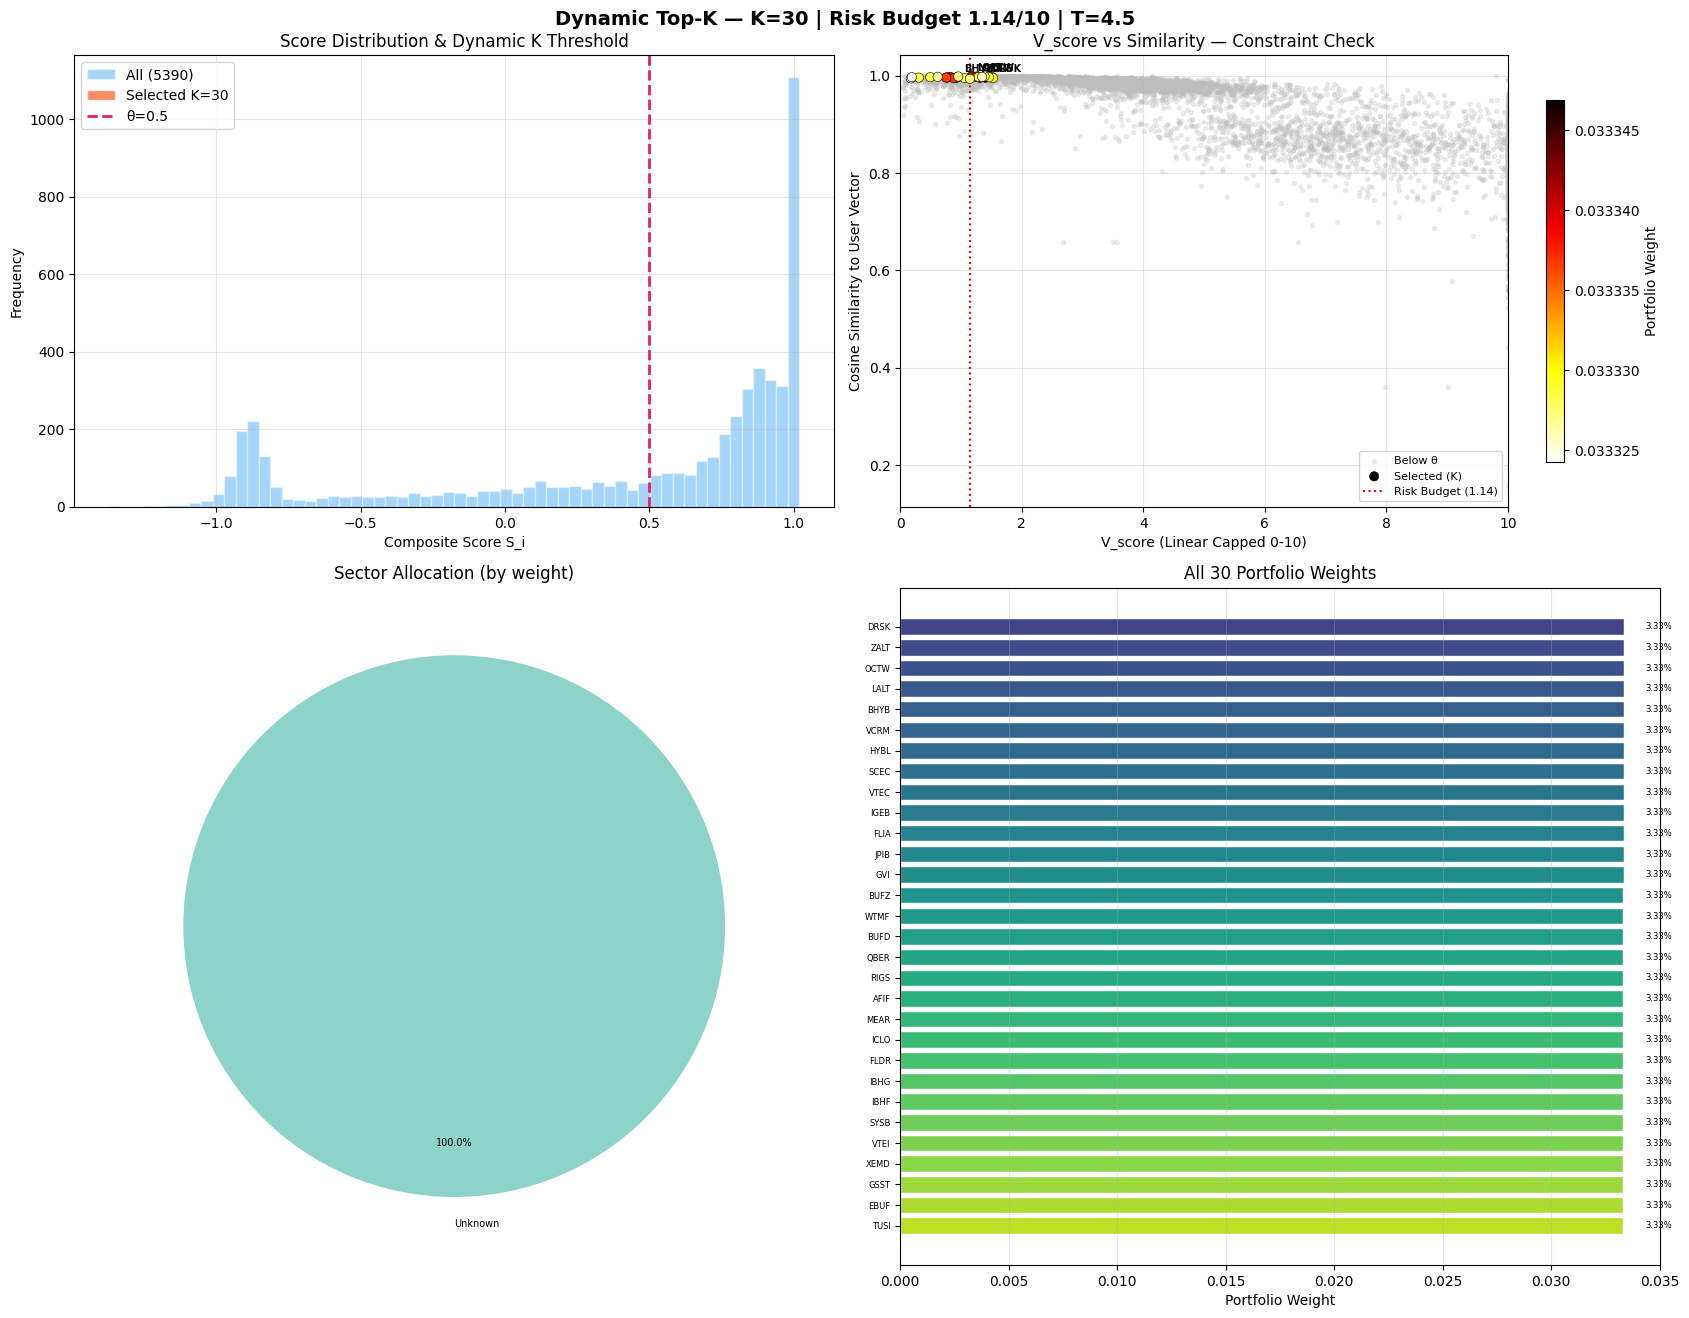


  SELECTED ASSETS (K=30) — Sorted by Score
  Rank  Ticker    Similarity   Raw Vol  V_score   Budget  Penalty%     Score |   Weight
  --------------------------------------------------------------------------------------------------------------------------------
  1     DRSK          0.9960     7.0%     1.40     1.14     0.1%    1.0201 |    3.33%
  2     ZALT          0.9966     6.5%     1.31     1.14     0.0%    1.0198 |    3.33%
  3     OCTW          0.9982     6.2%     1.24     1.14     0.0%    1.0196 |    3.33%
  4     LALT          0.9988     5.8%     1.17     1.14     0.0%    1.0192 |    3.33%
  5     BHYB          0.9975     4.8%     0.95     1.14     0.0%    1.0191 |    3.33%
  6     VCRM          0.9970     4.0%     0.79     1.14     0.0%    1.0191 |    3.33%
  7     HYBL          0.9962     4.6%     0.93     1.14     0.0%    1.0191 |    3.33%
  8     SCEC          0.9973     4.2%     0.83     1.14     0.0%    1.0190 |    3.33%
  9     VTEC          0.9962     3.8%     0.76   

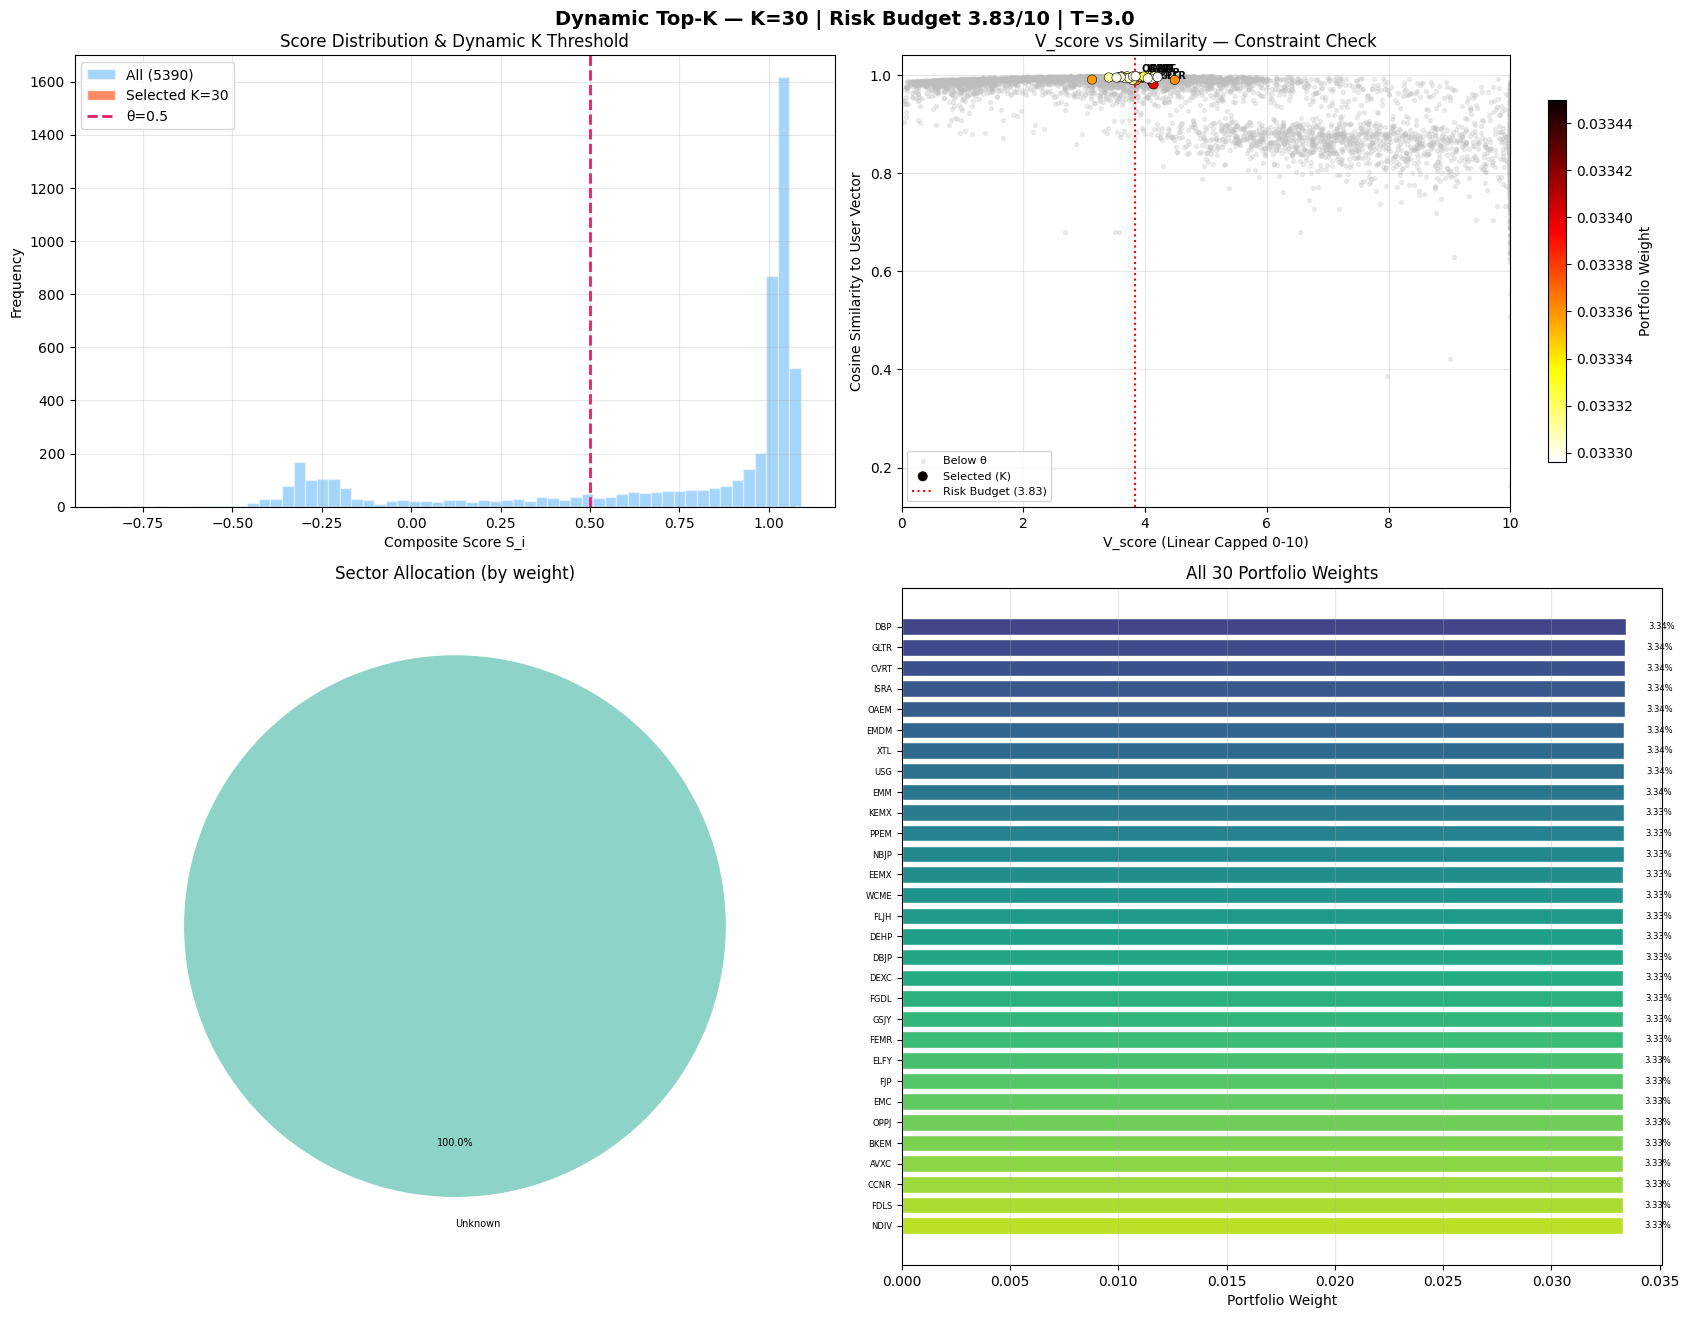


  SELECTED ASSETS (K=30) — Sorted by Score
  Rank  Ticker    Similarity   Raw Vol  V_score   Budget  Penalty%     Score |   Weight
  --------------------------------------------------------------------------------------------------------------------------------
  1     DBP           0.9871    20.5%     4.11     3.83     0.2%    1.0893 |    3.34%
  2     GLTR          0.9813    20.7%     4.14     3.83     0.2%    1.0847 |    3.34%
  3     CVRT          0.9951    19.8%     3.95     3.83     0.0%    1.0834 |    3.34%
  4     ISRA          0.9957    19.6%     3.93     3.83     0.0%    1.0834 |    3.34%
  5     OAEM          0.9964    19.2%     3.84     3.83     0.0%    1.0825 |    3.34%
  6     EMDM          0.9896    19.3%     3.86     3.83     0.0%    1.0820 |    3.34%
  7     XTL           0.9904    22.4%     4.49     3.83     1.1%    1.0814 |    3.34%
  8     USG           0.9911    15.6%     3.13     3.83     0.0%    1.0811 |    3.34%
  9     EMM           0.9975    18.1%     3.62   

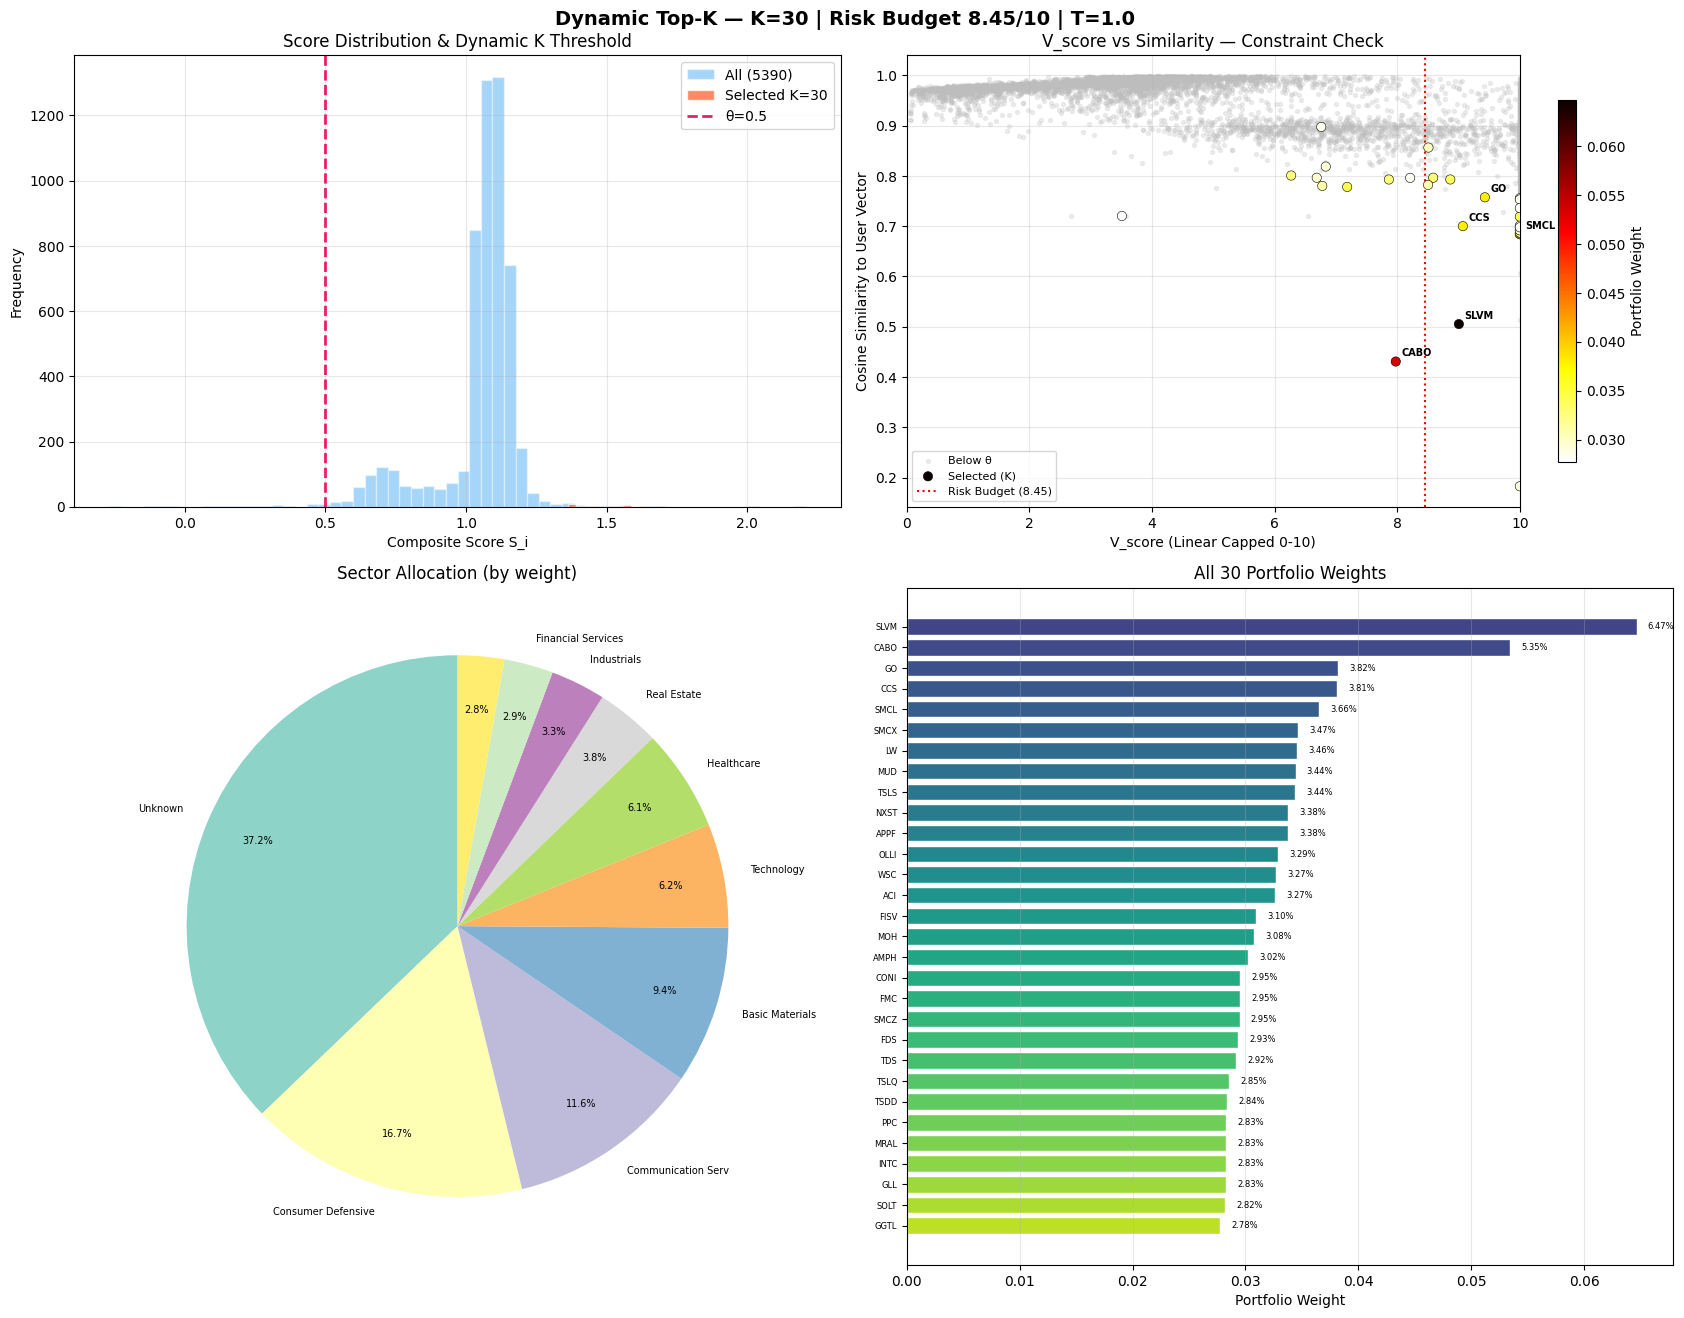


  SELECTED ASSETS (K=30) — Sorted by Score
  Rank  Ticker    Similarity   Raw Vol  V_score   Budget  Penalty%     Score |   Weight
  --------------------------------------------------------------------------------------------------------------------------------
  1     SLVM          0.5053    45.0%     9.01     8.45    12.7%    2.2078 |    6.47%
  2     CABO          0.4308    39.9%     7.98     8.45     0.0%    2.0177 |    5.35%
  3     GO            0.7575    47.1%     9.43     8.45    39.8%    1.6827 |    3.82%
  4     CCS           0.7001    45.4%     9.07     8.45    15.9%    1.6783 |    3.81%
  5     SMCL          0.6840   173.2%    10.00     8.45   100.0%    1.6376 |    3.66%
  6     SMCX          0.6855   206.5%    10.00     8.45   100.0%    1.5841 |    3.47%
  7     LW            0.7780    35.9%     7.18     8.45     0.0%    1.5817 |    3.46%
  8     MUD           0.6976    97.9%    10.00     8.45   100.0%    1.5778 |    3.44%
  9     TSLS          0.7188    75.8%    10.00   

,Profile,Risk,Start Cap,K (Assets),HHI,Wtd Vol,GFR,ETV,Obj Score
0,Conservative Retiree,2.0,"$500,000",30,333,5.13%,100.00%,"$173,375","173,375"
1,Balanced Growth (House + Retirement),5.0,"$150,000",30,333,19.32%,0.00%,$0,0
2,Aggressive Young Investor,9.0,"$50,000",30,351,87.39%,0.00%,$0,0


In [9]:
# ==========================================
# PART B: MULTI-PROFILE DYNAMIC TOP-K TEST
# ==========================================

TEST_PROFILES = [
    {
        "profile_name": "Conservative Retiree",
        "risk_tolerance": 2.0,
        "start_cap": 500000,
        "goals": {2: 50000, 5: 100000, 10: 200000}
    },
    {
        "profile_name": "Balanced Growth (House + Retirement)",
        "risk_tolerance": 5.0,
        "start_cap": 150000,
        "goals": {5: 60000, 20: 120000}
    },
    {
        "profile_name": "Aggressive Young Investor",
        "risk_tolerance": 9.0,
        "start_cap": 50000,
        "goals": {15: 80000, 30: 200000}
    },
]

all_profile_results = []

for profile in TEST_PROFILES:
    print("\n" + "\u2550" * 80)
    print(f"  TESTING PROFILE: {profile['profile_name']}")
    print("\u2550" * 80)
    
    # Step 1: Build user preference vector from profile inputs
    user_vec = build_user_preference_vector(DATA_CACHE, profile, PIPELINE_CONFIG)
    
    # Step 2: Score, filter, and allocate (reads theta/weights from PIPELINE_CONFIG)
    recs = recommend_and_allocate_member_b(
        dataset=DATA_CACHE,
        user_profile=profile,
        user_vector=user_vec,
        config=PIPELINE_CONFIG
    )
    
    # Step 3: Display comprehensive results
    stats = display_dynamic_top_k(DATA_CACHE, recs, profile, user_vec)
    
    # Step 4: Run simulation evaluation (Member C)
    sim_metrics = evaluate_portfolio_member_c(DATA_CACHE, recs, profile, config=PIPELINE_CONFIG)
    
    print(f"  \u2500\u2500\u2500 SIMULATION RESULTS \u2500\u2500\u2500")
    print(f"  Goal Fulfillment Rate (GFR): {sim_metrics['GFR']:.2%}")
    print(f"  Expected Terminal Value:     ${sim_metrics['ETV']:,.0f}")
    print(f"  Objective Score:             {sim_metrics['Objective_Function_Score']:,.0f}")
    print(f"  Total Simulations Run:       {sim_metrics['Total_Simulations']}")
    
    all_profile_results.append({
        "Profile": profile["profile_name"],
        "Risk": profile["risk_tolerance"],
        "Start Cap": f"${profile['start_cap']:,.0f}",
        "K (Assets)": stats["k"],
        "HHI": f"{stats['hhi']:.0f}",
        "Wtd Vol": f"{stats['weighted_volatility']:.2%}",
        "GFR": f"{sim_metrics['GFR']:.2%}",
        "ETV": f"${sim_metrics['ETV']:,.0f}",
        "Obj Score": f"{sim_metrics['Objective_Function_Score']:,.0f}"
    })

print("\n\n" + "\u2588" * 80)
print("\u2588  CROSS-PROFILE COMPARISON SUMMARY")
print("\u2588" * 80)
display(pd.DataFrame(all_profile_results))


### Threshold (θ) Sensitivity Analysis

How does the Dynamic K threshold affect each user profile's portfolio?

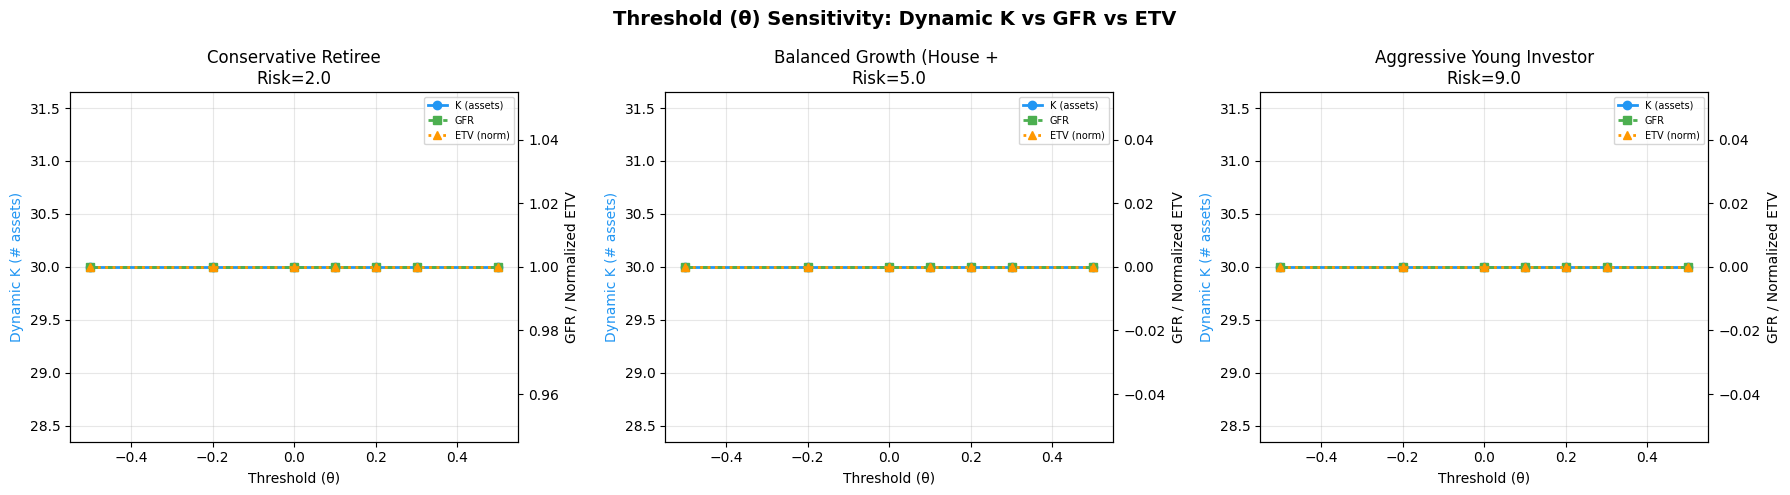


Threshold Analysis Complete.


In [10]:
# ==========================================
# THRESHOLD SENSITIVITY: How does theta affect
# recommendations for each risk profile?
# ==========================================

theta_grid = [-0.5, -0.2, 0.0, 0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Threshold (\u03b8) Sensitivity: Dynamic K vs GFR vs ETV", fontsize=14, fontweight='bold')

for ax_idx, profile in enumerate(TEST_PROFILES):
    user_vec = build_user_preference_vector(DATA_CACHE, profile, PIPELINE_CONFIG)

    k_vals, gfr_vals, etv_vals = [], [], []

    for theta_val in theta_grid:
        # Override theta for this test
        test_config = PIPELINE_CONFIG.copy()
        test_config["sim_dynamic_k_theta"] = theta_val
        
        recs = recommend_and_allocate_member_b(
            dataset=DATA_CACHE,
            user_profile=profile,
            user_vector=user_vec,
            config=test_config
        )
        metrics = evaluate_portfolio_member_c(DATA_CACHE, recs, profile, config=PIPELINE_CONFIG)

        k_vals.append(recs["k_selected"])
        gfr_vals.append(metrics["GFR"])
        etv_vals.append(metrics["ETV"])

    ax = axes[ax_idx]
    ax2 = ax.twinx()

    l1 = ax.plot(theta_grid, k_vals, 'o-', color='#2196F3', linewidth=2, markersize=6, label='K (assets)')
    l2 = ax2.plot(theta_grid, gfr_vals, 's--', color='#4CAF50', linewidth=2, markersize=6, label='GFR')
    l3 = ax2.plot(theta_grid, [e/max(max(etv_vals,default=1),1) for e in etv_vals], '^:', color='#FF9800', linewidth=2, markersize=6, label='ETV (norm)')

    ax.set_xlabel('Threshold (\u03b8)')
    ax.set_ylabel('Dynamic K (# assets)', color='#2196F3')
    ax2.set_ylabel('GFR / Normalized ETV')
    ax.set_title(f'{profile["profile_name"][:25]}\nRisk={profile["risk_tolerance"]}')
    ax.grid(alpha=0.3)

    lines = l1 + l2 + l3
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

print("\nThreshold Analysis Complete.")
